In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


In [4]:
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB
None
               Склад     Количество
count  301355.000000  301355.000000
mean        2.900652       2.951559
std         1.352221       2.998154
min         1.000000       0.000000
25%         2.000000       1.000000
50%         3.000000       2.000000
75%         4.000000       4.000000
max         5.000000     200.000000


Проверяем формат столбцов

In [ ]:
print(df.info())

Сразу переведем столбец "Дата" в правильный формат

In [5]:
df['Дата'] = pd.to_datetime(df['Дата'], errors='coerce', dayfirst=True)

Сгруппируйте данные по дате, посчитайте количество продаж

In [6]:
grouped_df = df.groupby('Дата').size().reset_index(name='Количество_продаж')

print(grouped_df.head())

        Дата  Количество_продаж
0 2018-01-02               1521
1 2018-01-03               1387
2 2018-01-04               1455
3 2018-01-05               1481
4 2018-01-06               1467


Вывести несколько первых строк сгруппированных данных

In [7]:
print(grouped_df.head())

        Дата  Количество_продаж
0 2018-01-02               1521
1 2018-01-03               1387
2 2018-01-04               1455
3 2018-01-05               1481
4 2018-01-06               1467


Нарисуйте график продаж у `grouped_df`

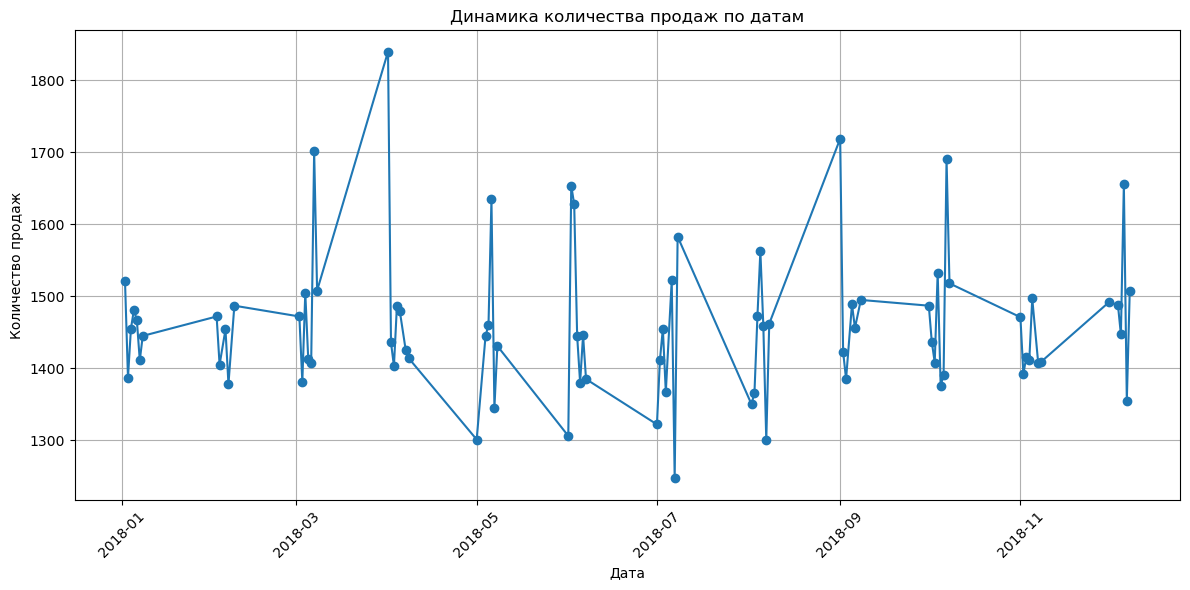

In [8]:
plt.figure(figsize=(12,6))
plt.plot(grouped_df['Дата'], grouped_df['Количество_продаж'], marker='o', linestyle='-')

plt.title('Динамика количества продаж по датам')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [ ]:
Начало периода: продажи идут на умеренном уровне, без сильных колебаний.
Середина года: заметен рост, достигающий пика — вероятно, весенние праздники или сезонный спрос.
Осень–зима: ещё один всплеск, связанный с предновогодними закупками.
Январь: резкое снижение, типичный постпраздничный спад.
График демонстрирует сезонные волны спроса: рост перед праздниками и спад после них.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [18]:
import numpy as np
import pandas as pd

df = pd.read_csv('data.csv')

print(df.columns)

col = 'Количество'

q1 = np.percentile(df[col], 25)
q3 = np.percentile(df[col], 75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

max_outlier = outliers.loc[outliers[col].idxmax()]

print("Максимальный выброс:")
print(max_outlier)


Index(['Дата', 'Склад', 'Контрагент', 'Номенклатура', 'Количество'], dtype='object')
Максимальный выброс:
Дата             2018-06-28
Склад                     1
Контрагент      address_208
Номенклатура      product_0
Количество              200
Name: 218822, dtype: object


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [21]:
import pandas as pd

df = pd.read_csv('data.csv')

df['Дата'] = pd.to_datetime(df['Дата'], errors='coerce', dayfirst=True)

summer_df = df[df['Дата'].dt.month.isin([6, 7, 8])]

# Фильтруем только среды (dayofweek: 0=понедельник, ..., 2=среда)
wednesday_df = summer_df[summer_df['Дата'].dt.dayofweek == 2]

# Группировка по складу и товару
grouped = (
    wednesday_df
    .groupby(['Склад', 'Номенклатура'])['Количество']   # ← замените 'Продажи' на реальное название столбца
    .sum()
    .reset_index()
)

# Находим топовый товар по каждому складу
top_products = grouped.loc[grouped.groupby('Склад')['Количество'].idxmax()]

print(top_products)


    Склад Номенклатура  Количество
1       1    product_1         596
34      2    product_2         575
46      3    product_1         479
69      4    product_1         479
92      5    product_1         458


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

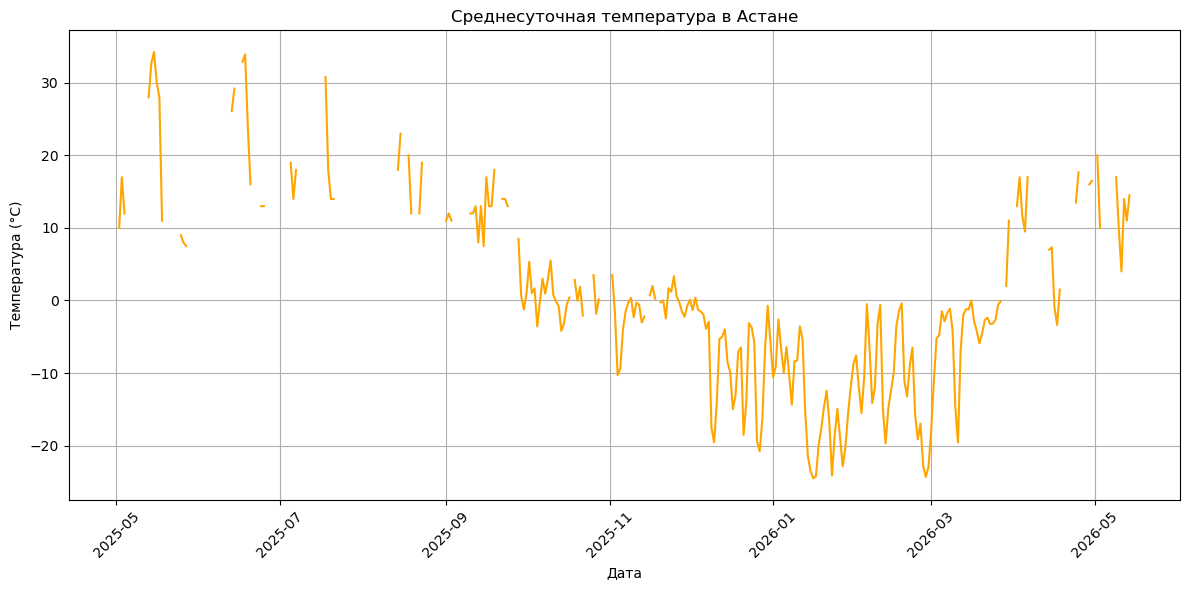

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

weather = pd.read_csv(
    "35188.01.05.2025.14.05.2026.1.0.0.ru.ansi.00000000.csv",
    sep=";", encoding="ansi", low_memory=False
)

weather.columns = weather.columns.str.strip()

weather['Дата'] = pd.to_datetime(weather.iloc[:,0], dayfirst=True, errors='coerce')

weather['T'] = pd.to_numeric(weather['T'], errors='coerce')

daily_temp = weather.groupby(weather['Дата'].dt.date)['T'].mean().reset_index()
daily_temp.rename(columns={'Дата':'Дата', 'T':'Температура'}, inplace=True)
daily_temp['Дата'] = pd.to_datetime(daily_temp['Дата'])

plt.figure(figsize=(12,6))
plt.plot(daily_temp['Дата'], daily_temp['Температура'], color='orange')
plt.title('Среднесуточная температура в Астане')
plt.xlabel('Дата')
plt.ylabel('Температура (°C)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()